# RQ1 — Baseline Prediction Performance

This Kaggle-ready notebook produces the actual table and figure for **RQ1** using `germany_rates.csv` from your GitHub repo.

In [4]:

# Kaggle-ready setup
# This notebook loads the Germany-filtered Airbnb dataset directly from your GitHub repo.
# If internet is disabled in Kaggle, upload germany_rates.csv as a Kaggle Dataset and change DATA_PATH below.

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR

RANDOM_STATE = 42
TARGET = "occupancy"
OUTPUT_DIR = Path("/kaggle/working/rq1_outputs") if Path("/kaggle/working").exists() else Path("rq1_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GITHUB_RAW_URL = "https://raw.githubusercontent.com/darr9725/Supervised_learning_project/main/Dataset/germany_rates.csv"
LOCAL_FALLBACKS = [
    "/kaggle/input/germany-rates/germany_rates.csv",
    "/kaggle/input/supervised-learning-project/germany_rates.csv",
    "/kaggle/input/airbnb-germany-rates/germany_rates.csv",
    "germany_rates.csv",
    "/mnt/data/germany_rates.csv"
]
DATA_PATH = os.environ.get("DATA_PATH", GITHUB_RAW_URL)


def load_data(path=DATA_PATH):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"Could not load from {path}. Trying local fallbacks...")
        last_error = e
        for p in LOCAL_FALLBACKS:
            if Path(p).exists():
                df = pd.read_csv(p)
                print(f"Loaded local file: {p}")
                break
        else:
            raise last_error
    if "country" in df.columns:
        df = df[df["country"].astype(str).str.lower().eq("germany")].copy()
    return df


def add_date_features(df):
    df = df.copy()
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month
        df["quarter"] = df["date"].dt.quarter
    return df


def make_xy(df, leakage_safe=True):
    df = add_date_features(df)
    base_drop = [TARGET, "listing_id", "date", "country"]
    # Exclude columns that can directly reveal the target after the month has already happened.
    leakage_cols = ["reserved_days", "vacant_days", "revenue", "native_revenue", "booked_rate_avg", "native_booked_rate_avg"]
    drop_cols = base_drop + (leakage_cols if leakage_safe else [])
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    y = df[TARGET].astype(float)
    return X, y


def get_columns(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
    return numeric_features, categorical_features


def make_preprocessor(X, scale_numeric=False):
    numeric_features, categorical_features = get_columns(X)
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_transformer = Pipeline(steps=numeric_steps)
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )


def make_model(name):
    if name == "Linear Regression":
        return LinearRegression()
    if name == "Ridge Regression":
        return Ridge(alpha=1.0, random_state=RANDOM_STATE)
    if name == "Decision Tree":
        return DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE)
    if name == "KNN":
        return KNeighborsRegressor(n_neighbors=15)
    if name == "Random Forest":
        return RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
    if name == "Extra Trees":
        return ExtraTreesRegressor(n_estimators=200, max_depth=14, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)
    if name == "Gradient Boosting":
        return GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    if name == "Hist Gradient Boosting":
        return HistGradientBoostingRegressor(max_iter=250, learning_rate=0.05, max_leaf_nodes=31, random_state=RANDOM_STATE)
    if name == "SVR":
        return SVR(C=10, epsilon=0.03, kernel="rbf")
    if name == "XGBoost":
        try:
            from xgboost import XGBRegressor
            return XGBRegressor(
                n_estimators=300, max_depth=4, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9,
                objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
            )
        except Exception:
            print("XGBoost unavailable; using Gradient Boosting fallback.")
            return GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    raise ValueError(f"Unknown model: {name}")


def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), # This did not work for argument squared: root_mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred)
    }


def train_eval_model(model_name, X_train, X_test, y_train, y_test, scale_numeric=False):
    pipe = Pipeline(steps=[
        ("preprocessor", make_preprocessor(X_train, scale_numeric=scale_numeric)),
        ("model", make_model(model_name))
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    metrics = evaluate_regression(y_test, pred)
    metrics["Model"] = model_name
    return pipe, metrics


def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def save_pdf(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")
    return path


df = load_data()
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (37389, 17)


,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city
0,1458671,2025-02-01,4,24,0.857,2054.0,85.6,85.6,76.0,2.0,2.0,83.0,83.0,1982.0,Germany,Hamburg,Hamburg
1,1458671,2025-03-01,13,18,0.581,1534.0,85.5,85.2,15.0,4.0,2.0,82.0,82.0,1478.0,Germany,Hamburg,Hamburg
2,1458671,2025-04-01,13,17,0.567,1473.0,87.5,86.6,27.0,2.0,2.0,80.0,81.0,1364.0,Germany,Hamburg,Hamburg
3,1458671,2025-05-01,16,15,0.484,1426.0,95.8,95.1,106.0,3.0,2.0,84.0,85.0,1262.0,Germany,Hamburg,Hamburg
4,1458671,2025-06-01,14,16,0.533,1576.0,97.1,98.5,179.0,6.0,2.0,87.0,86.0,1389.0,Germany,Hamburg,Hamburg


,Model,MAE,MSE,RMSE,R2
1,Decision Tree,0.179049,0.058269,0.241389,0.486346
2,KNN,0.211254,0.074616,0.273160,0.342238
0,Linear Regression,0.265169,0.094914,0.308081,0.163311


Saved table: rq1_outputs\rq1_baseline_model_performance.csv


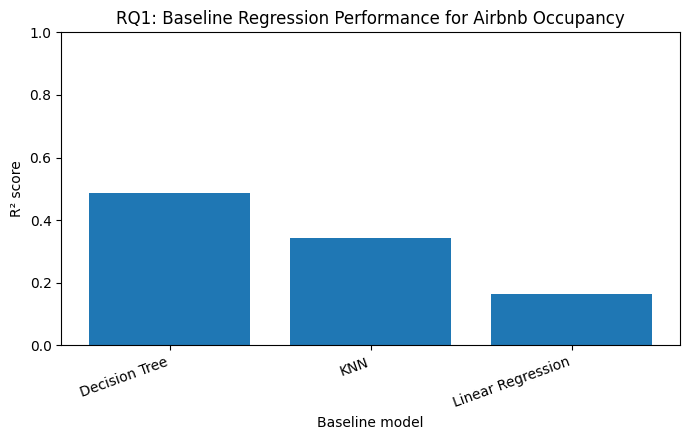

Saved figure: rq1_outputs\rq1_baseline_model_performance.pdf


WindowsPath('rq1_outputs/rq1_baseline_model_performance.pdf')

In [5]:

# RQ1 — Baseline Prediction Performance
X, y = make_xy(df, leakage_safe=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

baseline_models = ["Linear Regression", "Decision Tree", "KNN"]
rows = []
for model_name in baseline_models:
    scale = model_name in ["Linear Regression", "KNN"]
    pipe, metrics = train_eval_model(model_name, X_train, X_test, y_train, y_test, scale_numeric=scale)
    rows.append(metrics)

table = pd.DataFrame(rows)[["Model", "MAE", "MSE", "RMSE", "R2"]]
table = table.sort_values("RMSE")
display(table)
save_table(table, "rq1_baseline_model_performance.csv")

plt.figure(figsize=(7, 4.5))
plt.bar(table["Model"], table["R2"])
plt.title("RQ1: Baseline Regression Performance for Airbnb Occupancy")
plt.xlabel("Baseline model")
plt.ylabel("R² score")
plt.ylim(0, max(1.0, table["R2"].max() + 0.05))
plt.xticks(rotation=20, ha="right")
save_pdf("rq1_baseline_model_performance.pdf")
